## 1. Setup

Install required packages and import all libraries used throughout the pipeline.

In [1]:
!pip install pandas numpy scikit-learn xgboost pymongo matplotlib seaborn --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 18.1 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from pymongo import MongoClient

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# consistent plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

## 2. Load Data

Load the CSV built by the pipeline scripts. Each row is one quarterback-game observation with pregame structural features and actual passing yards as the outcome.

In [3]:
df = pd.read_csv("data/qb_games.csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nSample:")
df.head()

Shape: (1762, 29)

Columns: ['season', 'week', 'game_id', 'player_id', 'player_name', 'team', 'opponent', 'home_team', 'away_team', 'game_date', 'passing_yards', 'pass_attempts', 'temp', 'wind', 'time_of_day', 'spread_line', 'total_line', 'team_attempts', 'qb_pass_share', 'yards_last5', 'yards_last5_std', 'prev_game_date', 'days_rest', 'bad_weather', 'is_home', 'opp_epa_per_pass_allowed', 'opp_success_rate_allowed', 'opp_air_yards_allowed', 'opp_yac_allowed']

Sample:


,season,week,game_id,player_id,player_name,team,opponent,home_team,away_team,game_date,...,yards_last5,yards_last5_std,prev_game_date,days_rest,bad_weather,is_home,opp_epa_per_pass_allowed,opp_success_rate_allowed,opp_air_yards_allowed,opp_yac_allowed
0,2020,3,2020_03_TB_DEN,00-0019596,T.Brady,TB,DEN,DEN,TB,2020-09-27,...,228.0,15.556349,2020-09-20,7.0,0,0,0.125698,0.521645,5.934487,4.551724
1,2020,4,2020_04_LAC_TB,00-0019596,T.Brady,TB,LAC,TB,LAC,2020-10-04,...,251.0,41.327957,2020-09-27,7.0,0,1,0.001203,0.470173,6.741557,4.695603
2,2020,5,2020_05_TB_CHI,00-0019596,T.Brady,TB,CHI,CHI,TB,2020-10-08,...,280.5,67.968130,2020-10-04,4.0,0,0,-0.027056,0.443798,8.567439,4.297533
3,2020,6,2020_06_GB_TB,00-0019596,T.Brady,TB,GB,TB,GB,2020-10-18,...,275.0,60.133186,2020-10-08,10.0,0,1,0.107468,0.512979,8.098753,5.068612
4,2020,8,2020_08_TB_NYG,00-0019596,T.Brady,TB,NYG,NYG,TB,2020-11-02,...,290.8,85.546479,2020-10-25,8.0,0,0,0.130250,0.539154,7.140581,4.811624


## 3. Create Prediction Target

The goal is to predict a quarterback's passing yards in their **next** game, using only information available before that game is played. We sort chronologically within each player, shift passing yards forward by one row, and drop the final game for each quarterback (which has no future label to predict).

Importantly, `yards_last5` and `yards_last5_std` are present in the dataset but are **intentionally excluded** from the model feature set. The core research question is whether structural pregame context alone (opponent defense quality, market lines, usage share, weather, rest) can predict passing volume without feeding the model the quarterback's own historical yardage.

In [4]:
df = df.sort_values(["player_id", "season", "week"]).reset_index(drop=True)

# shift passing_yards forward by one within each QB to create next-game target
df["target_next_yards"] = df.groupby("player_id")["passing_yards"].shift(-1)

# drop rows with no future label (last game of each QB's run)
df = df.dropna(subset=["target_next_yards"])

print("Rows after target creation:", len(df))
print("Target stats:\n", df["target_next_yards"].describe().round(1))

Rows after target creation: 1632
Target stats:
 count    1632.0
mean      208.0
std        95.5
min        -4.0
25%       152.8
50%       215.0
75%       273.0
max       525.0
Name: target_next_yards, dtype: float64


## 4. Store in MongoDB and Retrieve

Insert the analysis-ready records into MongoDB Atlas, then pull them back out. This round-trip confirms that the document store is working correctly and that retrieved data matches what was inserted.

In [5]:
client = MongoClient(
    "mongodb+srv://<username>:<password>@cluster0.6mite1b.mongodb.net/?appName=Cluster0"
) # username and password submitted as a comment on my Canvas assignment

db = client["project2_db"]
collection = db["qb_games"]

# clear existing documents before re-inserting
collection.delete_many({})

docs = df.to_dict("records")
collection.insert_many(docs)

print(f"Inserted {len(docs)} documents into MongoDB")

Inserted 1632 documents into MongoDB


In [6]:
# retrieve all documents back from MongoDB
cursor = collection.find({})
df_mongo = pd.DataFrame(list(cursor))

# drop the MongoDB-generated _id field
if "_id" in df_mongo.columns:
    df_mongo = df_mongo.drop(columns=["_id"])

print("Retrieved shape:", df_mongo.shape)
df_mongo.head()

Retrieved shape: (1632, 30)


,season,week,game_id,player_id,player_name,team,opponent,home_team,away_team,game_date,...,yards_last5_std,prev_game_date,days_rest,bad_weather,is_home,opp_epa_per_pass_allowed,opp_success_rate_allowed,opp_air_yards_allowed,opp_yac_allowed,target_next_yards
0,2020,3,2020_03_TB_DEN,00-0019596,T.Brady,TB,DEN,DEN,TB,2020-09-27,...,15.556349,2020-09-20,7.0,0,0,0.125698,0.521645,5.934487,4.551724,369.0
1,2020,4,2020_04_LAC_TB,00-0019596,T.Brady,TB,LAC,TB,LAC,2020-10-04,...,41.327957,2020-09-27,7.0,0,1,0.001203,0.470173,6.741557,4.695603,253.0
2,2020,5,2020_05_TB_CHI,00-0019596,T.Brady,TB,CHI,CHI,TB,2020-10-08,...,67.968130,2020-10-04,4.0,0,0,-0.027056,0.443798,8.567439,4.297533,166.0
3,2020,6,2020_06_GB_TB,00-0019596,T.Brady,TB,GB,TB,GB,2020-10-18,...,60.133186,2020-10-08,10.0,0,1,0.107468,0.512979,8.098753,5.068612,279.0
4,2020,8,2020_08_TB_NYG,00-0019596,T.Brady,TB,NYG,NYG,TB,2020-11-02,...,85.546479,2020-10-25,8.0,0,0,0.130250,0.539154,7.140581,4.811624,209.0


## 5. Define Feature Set

Define the structural pregame features used as model inputs. Historical passing yards (`yards_last5`, `yards_last5_std`) are deliberately excluded. They are retained in the dataset for reference but are not fed to any model.

In [7]:
FEATURES = [
    # opponent pass-defense quality (rolling 5-game lagged)
    "opp_epa_per_pass_allowed",
    "opp_success_rate_allowed",
    "opp_air_yards_allowed",
    "opp_yac_allowed",
    # betting market context
    "spread_line",
    "total_line",
    # usage / role
    "qb_pass_share",
    # scheduling
    "days_rest",
    "is_home",
    # weather
    "temp",
    "wind",
    "bad_weather",
]

TARGET = "target_next_yards"

# verify all features are present
missing = [f for f in FEATURES if f not in df_mongo.columns]
if missing:
    print("WARNING! Missing columns:", missing)
else:
    print("All features present. Feature count:", len(FEATURES))

All features present. Feature count: 12


## 6. Temporal Train / Test Split

We split by season rather than randomly sampling rows. All games from 2020–2023 form the training set; the 2024 season is held out as the test set. This respects the temporal structure of the data and prevents any future information from leaking into training.

In [8]:
train = df_mongo[df_mongo["season"] < 2024].copy()
test  = df_mongo[df_mongo["season"] == 2024].copy()

print(f"Train: {len(train)} rows ({train['season'].min()}–{train['season'].max()})")
print(f"Test: {len(test)} rows (2024)")

# cast to float after MongoDB round trip
X_train = train[FEATURES].astype(float)
y_train = train[TARGET].astype(float)

X_test = test[FEATURES].astype(float)
y_test = test[TARGET].astype(float)

Train: 1288 rows (2020–2023)
Test: 344 rows (2024)


## 7. Evaluation Helper

A single function to compute MAE, RMSE, and R² consistently across all models.

In [14]:
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"{name}:")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²: {r2:.4f}")
    return {"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2}

## 8. Baseline Model

The baseline predicts the training-set mean passing yards for every observation. This gives a floor for comparison, and any model worth using should beat it.

In [15]:
baseline_pred = np.full(len(y_test), y_train.mean())

print(f"Baseline prediction (train mean): {y_train.mean():.1f} yards")
results = [evaluate("Baseline (train mean)", y_test, baseline_pred)]

Baseline prediction (train mean): 208.3 yards
Baseline (train mean):
MAE: 70.36
RMSE: 89.90
R²: -0.0003


## 9. Ridge Regression

Ridge regression is a regularized linear model. Including a `StandardScaler` in the pipeline ensures that features on different scales (e.g. `days_rest` vs `opp_epa_per_pass_allowed`) are normalized before the penalty is applied.

In [16]:
ridge_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  Ridge(alpha=1.0))
])

ridge_pipe.fit(X_train, y_train)
ridge_pred = ridge_pipe.predict(X_test)

results.append(evaluate("Ridge Regression", y_test, ridge_pred))

Ridge Regression:
MAE: 62.95
RMSE: 81.02
R²: 0.1875


## 10. Random Forest

Random Forest is an ensemble of decision trees trained on random subsamples of the data. The shallow `max_depth` and high `min_samples_split` here constrain individual trees to avoid overfitting on a dataset of this size.

In [17]:
rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=3,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

results.append(evaluate("Random Forest", y_test, rf_pred))

Random Forest:
MAE: 62.96
RMSE: 80.92
R²: 0.1896


## 11. XGBoost

XGBoost is a gradient-boosted tree model that iteratively fits residuals.

In [18]:
xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    verbosity=0
)

xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)
xgb_pred = xgb.predict(X_test)

results.append(evaluate("XGBoost", y_test, xgb_pred))

XGBoost:
MAE: 62.51
RMSE: 79.25
R²: 0.2226


## 12. Results Summary Table

Compare all models on MAE, RMSE, and R². Lower MAE/RMSE and higher R² are better.

In [19]:
results_df = pd.DataFrame(results).set_index("Model")
results_df["MAE"] = results_df["MAE"].round(2)
results_df["RMSE"] = results_df["RMSE"].round(2)
results_df["R2"] = results_df["R2"].round(4)

results_df.sort_values("MAE")

,MAE,RMSE,R2
Model,,,
XGBoost,62.51,79.25,0.2226
Ridge Regression,62.95,81.02,0.1875
Random Forest,62.96,80.92,0.1896
Baseline (train mean),70.36,89.90,-0.0003


We can see that all three models improved upon the baseline prediction. XGBoost was the optimal model, but all three models were very close (the MAEs for the three models were all within the range of 0.5 yard).

## 13. Visualization: Model Comparison

Side-by-side bar charts comparing MAE, RMSE, and R² across all models. The dashed line on each panel marks the baseline, making it easy to see how much each model improves over simply predicting the mean.

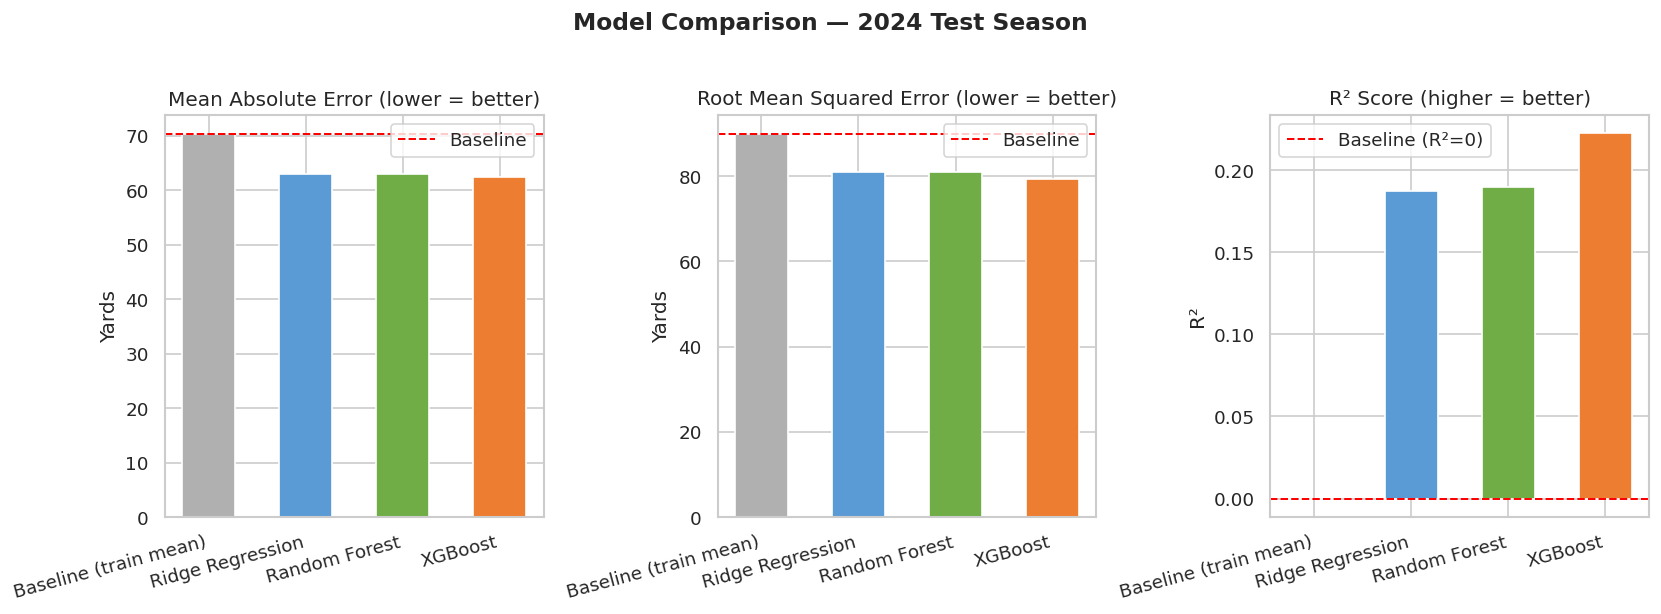

In [23]:
models = results_df.index.tolist()
mae_vals = results_df["MAE"].values
rmse_vals = results_df["RMSE"].values
r2_vals = results_df["R2"].values

x = np.arange(len(models))
width = 0.55
colors = ["#b0b0b0", "#5b9bd5", "#70ad47", "#ed7d31"]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Model Comparison — 2024 Test Season", fontsize=14, fontweight="bold", y=1.02)

# MAE
axes[0].bar(x, mae_vals, width=width, color=colors)
axes[0].axhline(mae_vals[0], color="red", linestyle="--", linewidth=1.2, label="Baseline")
axes[0].set_title("Mean Absolute Error (lower = better)")
axes[0].set_xticks(x); axes[0].set_xticklabels(models, rotation=15, ha="right")
axes[0].set_ylabel("Yards")
axes[0].legend()

# RMSE
axes[1].bar(x, rmse_vals, width=width, color=colors)
axes[1].axhline(rmse_vals[0], color="red", linestyle="--", linewidth=1.2, label="Baseline")
axes[1].set_title("Root Mean Squared Error (lower = better)")
axes[1].set_xticks(x); axes[1].set_xticklabels(models, rotation=15, ha="right")
axes[1].set_ylabel("Yards")
axes[1].legend()

# R²
axes[2].bar(x, r2_vals, width=width, color=colors)
axes[2].axhline(0, color="red", linestyle="--", linewidth=1.2, label="Baseline (R²=0)")
axes[2].set_title("R² Score (higher = better)")
axes[2].set_xticks(x); axes[2].set_xticklabels(models, rotation=15, ha="right")
axes[2].set_ylabel("R²")
axes[2].legend()

plt.tight_layout()
plt.savefig("model_comparison.png", bbox_inches="tight")
plt.show()

## 14. Visualization: Actual vs. Predicted

Scatter plots of actual vs. predicted passing yards for each non-baseline model on the 2024 test set. Points along the diagonal indicate accurate predictions. The spread around the diagonal reflects the model's remaining error.

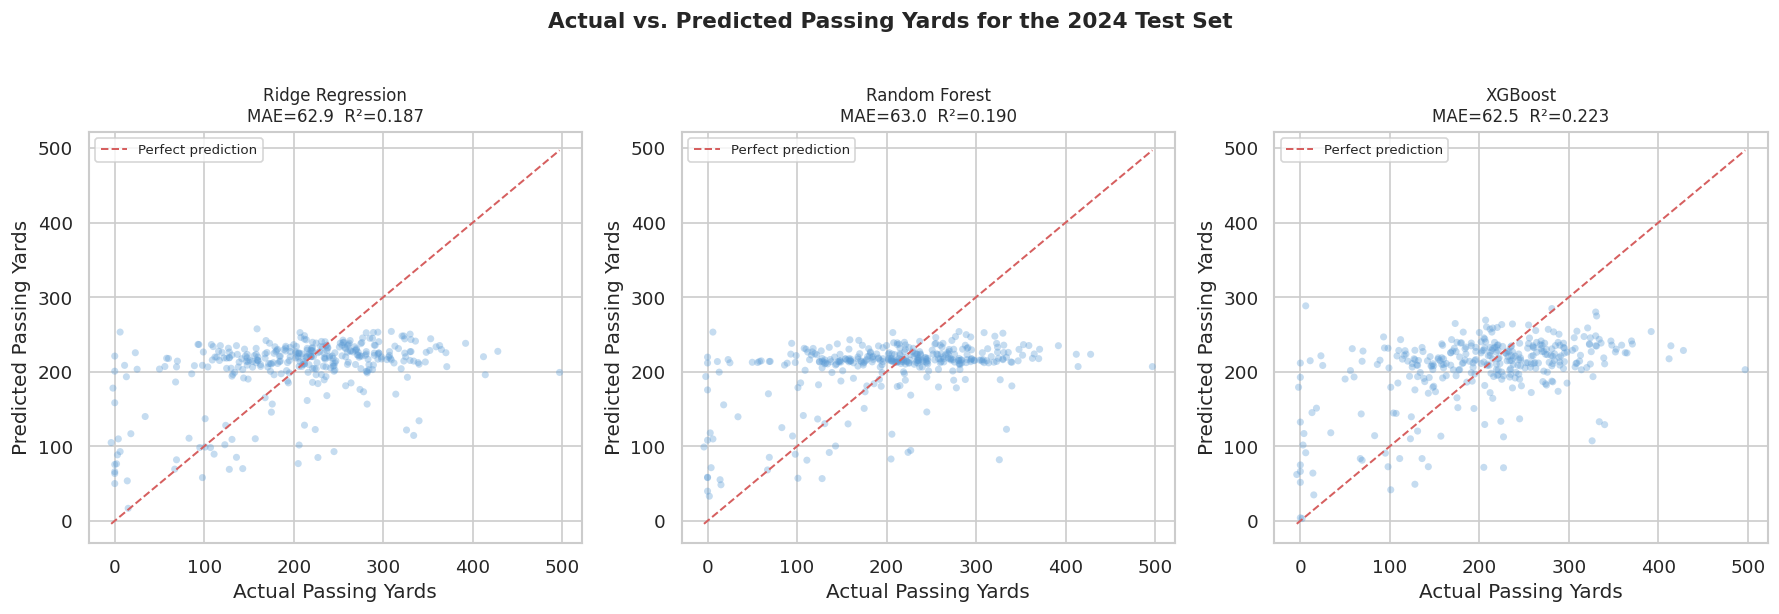

In [24]:
model_preds = {
    "Ridge Regression": ridge_pred,
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred,
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Actual vs. Predicted Passing Yards for the 2024 Test Set",
             fontsize=13, fontweight="bold", y=1.02)

for ax, (name, pred) in zip(axes, model_preds.items()):
    ax.scatter(y_test, pred, alpha=0.35, s=18, color="#5b9bd5", edgecolors="none")

    # perfect prediction line
    lo = min(y_test.min(), pred.min())
    hi = max(y_test.max(), pred.max())
    ax.plot([lo, hi], [lo, hi], "r--", linewidth=1.2, label="Perfect prediction")

    mae_val = mean_absolute_error(y_test, pred)
    r2_val  = r2_score(y_test, pred)
    ax.set_title(f"{name}\nMAE={mae_val:.1f}  R²={r2_val:.3f}", fontsize=10)
    ax.set_xlabel("Actual Passing Yards")
    ax.set_ylabel("Predicted Passing Yards")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("actual_vs_predicted.png", bbox_inches="tight")
plt.show()

## 15. Visualization: Residuals

Residual plots (predicted minus actual) for each model. A well-behaved model should show residuals scattered randomly around zero with no obvious pattern. Systematic curvature or heteroskedasticity would indicate the model is missing structure in the data.

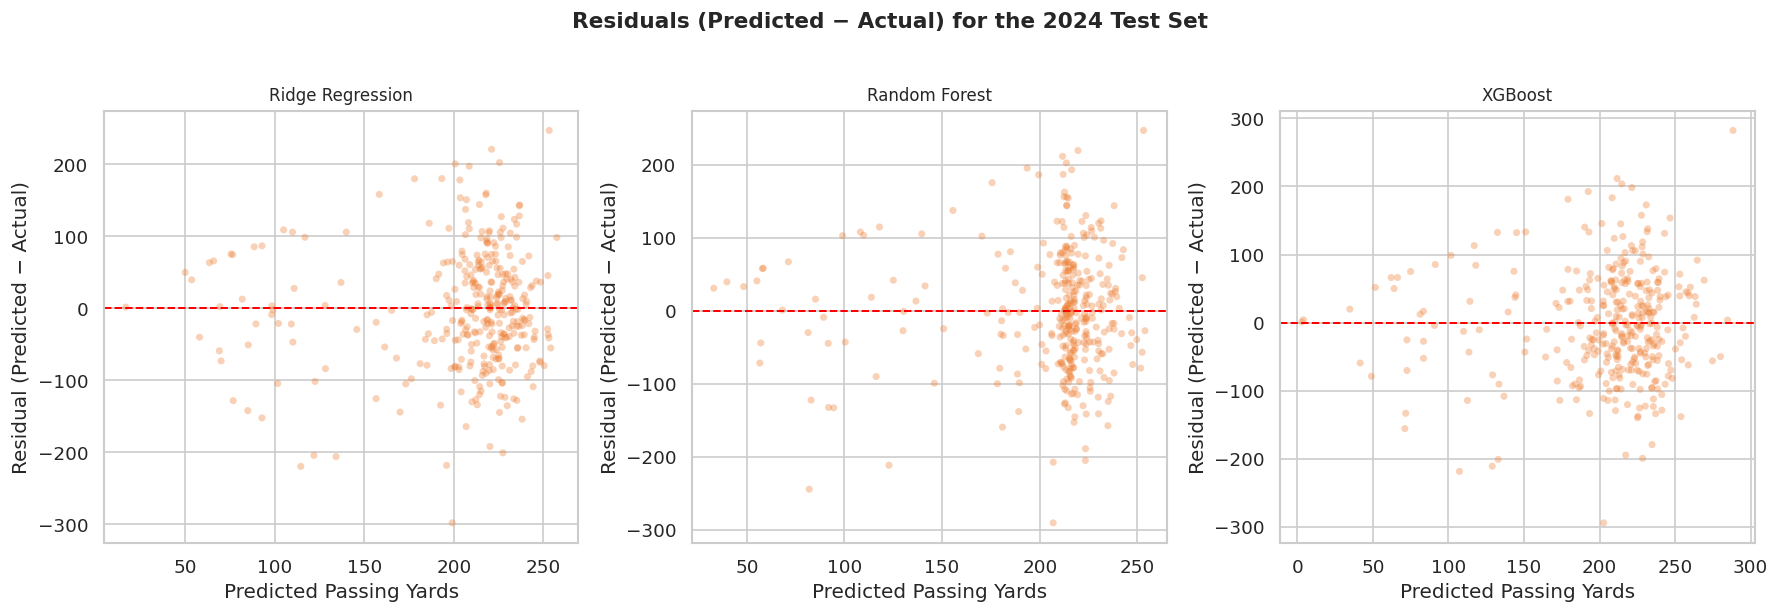

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Residuals (Predicted − Actual) for the 2024 Test Set",
             fontsize=13, fontweight="bold", y=1.02)

for ax, (name, pred) in zip(axes, model_preds.items()):
    residuals = pred - y_test.values

    ax.scatter(pred, residuals, alpha=0.35, s=18, color="#ed7d31", edgecolors="none")
    ax.axhline(0, color="red", linestyle="--", linewidth=1.2)

    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Predicted Passing Yards")
    ax.set_ylabel("Residual (Predicted − Actual)")

plt.tight_layout()
plt.savefig("residuals.png", bbox_inches="tight")
plt.show()

## 16. Visualization: Feature Importance

Feature importance from Random Forest (mean decrease in impurity) and XGBoost (total gain). These tell us which structural pregame features the models relied on most heavily when making predictions so they can help us interpret whether the hypothesis holds that game context and opponent defense drive passing volume.

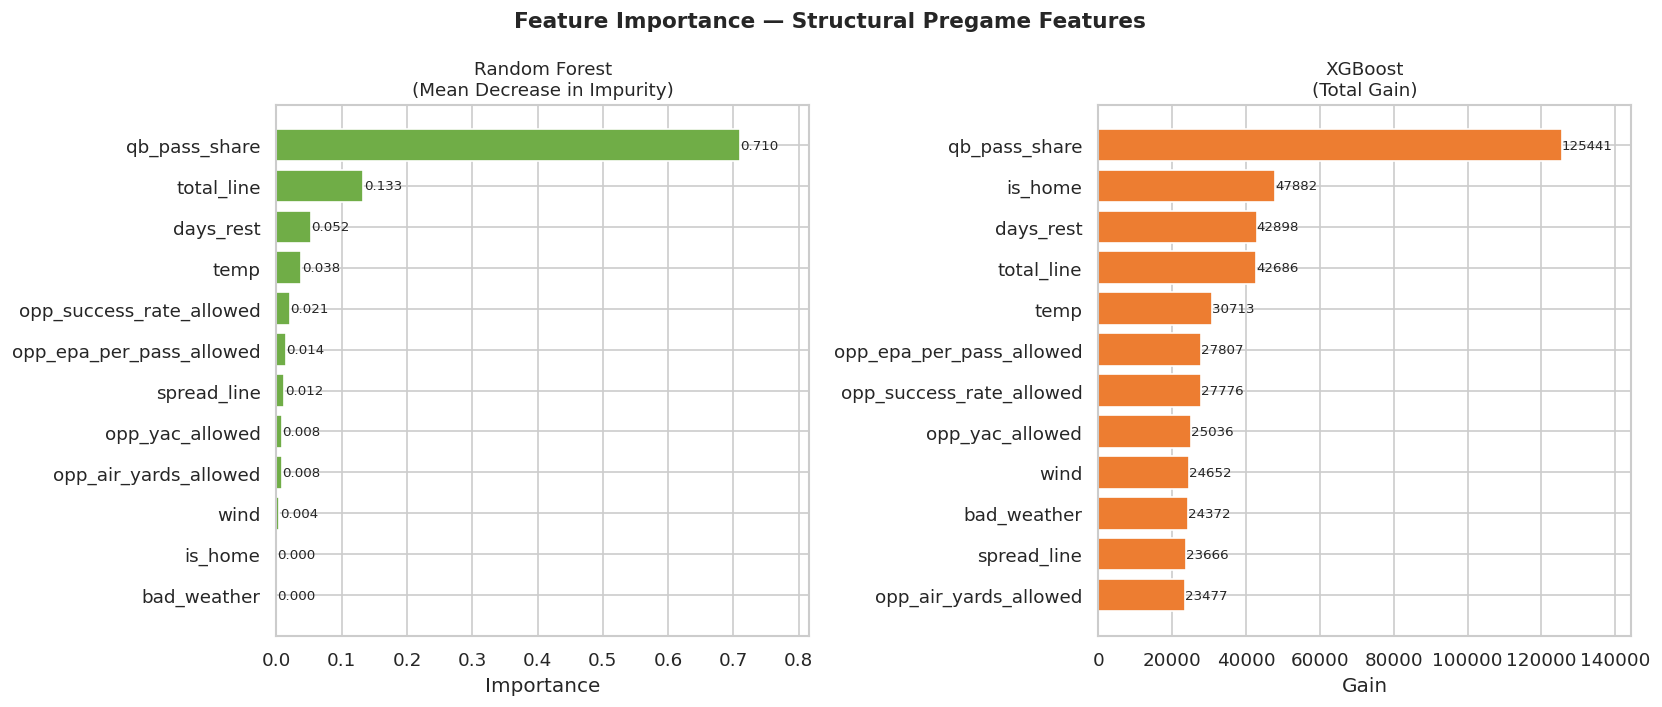

In [26]:
# Random Forest importance
rf_importance = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()

# XGBoost importance (gain)
xgb_importance = pd.Series(
    xgb.get_booster().get_score(importance_type="gain"),
    name="XGBoost Gain"
).reindex(FEATURES).fillna(0).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Feature Importance — Structural Pregame Features",
             fontsize=13, fontweight="bold")

# Random Forest
bars_rf = axes[0].barh(rf_importance.index, rf_importance.values, color="#70ad47")
axes[0].set_title("Random Forest\n(Mean Decrease in Impurity)", fontsize=11)
axes[0].set_xlabel("Importance")
axes[0].set_xlim(0, rf_importance.values.max() * 1.15)
for bar, val in zip(bars_rf, rf_importance.values):
    axes[0].text(val + 0.001, bar.get_y() + bar.get_height() / 2,
                 f"{val:.3f}", va="center", fontsize=8)

# XGBoost
bars_xgb = axes[1].barh(xgb_importance.index, xgb_importance.values, color="#ed7d31")
axes[1].set_title("XGBoost\n(Total Gain)", fontsize=11)
axes[1].set_xlabel("Gain")
axes[1].set_xlim(0, xgb_importance.values.max() * 1.15)
for bar, val in zip(bars_xgb, xgb_importance.values):
    axes[1].text(val + 0.5, bar.get_y() + bar.get_height() / 2,
                 f"{val:.0f}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig("feature_importance.png", bbox_inches="tight")
plt.show()

## 17. Visualization: Top Features Combined Heatmap

A normalized heatmap making it easy to compare which features both models agree are important versus where they diverge.

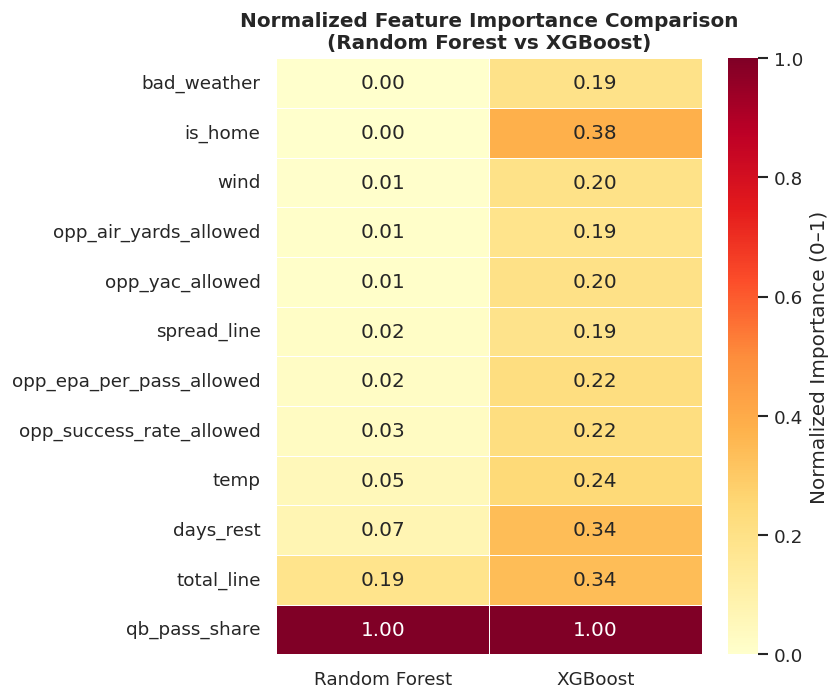

In [27]:
# normalize each model's importances to 0–1 for comparison
rf_norm = rf_importance / rf_importance.max()
xgb_norm = xgb_importance / xgb_importance.max()

importance_df = pd.DataFrame({
    "Random Forest": rf_norm,
    "XGBoost": xgb_norm,
}).sort_values("Random Forest")

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    importance_df,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.4,
    ax=ax,
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Normalized Importance (0–1)"}
)
ax.set_title("Normalized Feature Importance Comparison\n(Random Forest vs XGBoost)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("feature_importance_heatmap.png", bbox_inches="tight")
plt.show()

## 18. Quantification of Uncertainty

In [28]:
# define numerical features and their roles
numerical_features = {
    "passing_yards": "Target",
    "days_rest": "Predictor",
    "spread_line": "Predictor",
    "total_line": "Predictor",
    "qb_pass_share": "Predictor",
    "opp_epa_per_pass_allowed": "Predictor",
    "opp_success_rate_allowed": "Predictor",
    "opp_air_yards_allowed": "Predictor",
    "opp_yac_allowed": "Predictor",
    "bad_weather": "Predictor",
    "is_home": "Predictor",
    "yards_last5": "Excluded",
    "yards_last5_std": "Excluded",
}

# compute stats
rows = []
for col, role in numerical_features.items():
    s = df[col]
    missing_pct = round(s.isna().mean() * 100, 1)
    rows.append({
        "Feature": col,
        "Role": role,
        "Mean": round(s.mean(), 3),
        "Std Dev": round(s.std(), 3),
        "Min": round(s.min(), 3),
        "25th Pct": round(s.quantile(0.25), 3),
        "Median": round(s.median(), 3),
        "75th Pct": round(s.quantile(0.75), 3),
        "Max": round(s.max(), 3),
        "Missing %": f"{missing_pct}%",
    })

summary = pd.DataFrame(rows)
print(summary.to_markdown(index=False))

| Feature                  | Role      |    Mean |   Std Dev |     Min |   25th Pct |   Median |   75th Pct |      Max | Missing %   |
|:-------------------------|:----------|--------:|----------:|--------:|-----------:|---------:|-----------:|---------:|:------------|
| passing_yards            | Target    | 210.377 |    94.385 |  -4     |    157     |  217     |    274     |  525     | 0.0%        |
| days_rest                | Predictor |  29.274 |    83.111 |   4     |      7     |    7     |     10     | 1071     | 0.0%        |
| spread_line              | Predictor |   1.862 |     6.385 | -17     |     -3     |    3     |      6.5   |   20     | 0.0%        |
| total_line               | Predictor |  44.715 |     4.556 |  28.5   |     42     |   44.5   |     47.5   |   58     | 0.0%        |
| qb_pass_share            | Predictor |   0.885 |     0.266 |   0.019 |      0.971 |    1     |      1     |    1     | 0.0%        |
| opp_epa_per_pass_allowed | Predictor |   0.025 |     